# Drought Metrics

This notebook calculates two drought metrics, the Palmer Drought Severity Index (PDSI) and the Evaporative Demand Drought Index (EDDI), using WRF data in the AE catalog. Both PDSI and EDDI require Potential Evapotranspiration (PET). PET is computed first using the Penman-Monteith method. At the end of the notebook, the user will be able to export monthly PDSI and EDDI for under different global warming levels for a specific lat/lon as netcdf files to be used for further analyses.   

**Intended Application:** As a user, I want to <font color="red"> export future drought indices for different global warming levels </font> by:
1. Calculating PET using the Penman-Montieth Method
2. Calculating the PDSI using PET and exporting the monthly timeseries to a netcdf
3. Calculating the EDDI using PET and exporting the monthly timeseries to a netcdf

**Runtime:** With the default settings, this notebook takes approximately 25 minutes to run from start to finish. Modifications to selections may increase the runtime.

**Troubleshooting:** Getting an `IndexError: index 40 is out of bounds for axis 0 with size 40` when trying to run the PDSI calculation? Try changing your lat/lon or point of interest further away from the boundaries of our 3 km WRF domain (as seen in [<span style="color:blue">this graphic</span>](https://analytics.cal-adapt.org/faq/#what-data-is-available)).

## Step 0: Setup

In [1]:
# Install climate_indices at a specific commit compatible with the AE hub environment
!pip install -qq git+https://github.com/monocongo/climate_indices.git@43c5451

In [2]:
import climakitae as ck
import xclim
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import flox
from pyproj import CRS
from dask.diagnostics import ProgressBar
from climate_indices.palmer import pdsi as palmer_pdsi
from xclim.indices.stats import standardized_index

In [165]:
# Define the lat/lon for the location of interest and the variables needed for the Penman-Monteith PET method
LAT = 37.787964
# LAT = 37.830358
LON = -122.065063
# LON = -122.261082
WARMING_LEVELS = [0.8, 2.0]

## Step 1: Fetch Data and Calculate PET

**IMPORTANT NOTE**: The following cell saves the intermediate data required for PET into an `input_data` directory. If you change the lat/lon coordinate from above and DON'T delete or move the data already inside the `input_data` directory, it will just re-read the same data files.

### Penman-Monteith PET Method (most physically consistent)
We will be using the PET method for calculating PDSI, since it is the most physically consistent method. Below, we list out the variables we will need.

**Variables needed:**
- `t2` (hourly) → daily `tasmin` and `tasmax` derived via resample
- `relative humidity`
- `radiation flux`
    - rsds (daily)
    - rsus (hourly → daily mean)
    - rlds (daily)
    - rlus (hourly → daily mean)
- `wind speed (10m wind will be converted to 2m)`

In [161]:
# Initialize the ClimateData object and define the processors needed.
cd = ck.ClimateData(verbosity=-2)
processes = {
    "clip": (LAT, LON),
    "warming_level": {
        "warming_levels": WARMING_LEVELS,
        "add_dummy_time": True
    },
}

def rename_sims_to_gcm(ds):
    """"Renames the 'sim' coordinate in the dataset to only contain the GCM name for easier grouping later."""
    ds = ds.copy()
    new_sims = [s.split('_')[2] for s in ds['sim'].values]
    ds['sim'] = ('sim', new_sims)
    return ds

def fetch(variable, table_id="day", units=None):
    """Fetch a WRF variable from the AE catalog with the configured processes."""
    proc = {**processes}
    if units is not None:
        proc["convert_units"] = units
    return (
        cd.catalog("cadcat")
        .activity_id("WRF")
        .institution_id("UCLA")
        .table_id(table_id)
        .grid_label("d03")
        .variable(variable)
        .processes(proc)
        .get()
    )

def get_and_transform(variable, table_id="day", units=None, transform=None):
    """Fetching variables and applying a transformation if it's passed in."""
    print(f"\nFetching {variable}...")
    da = fetch(variable, table_id=table_id, units=units)
    da = da.unify_chunks()  # Ensure the data is chunked for Dask processing
    if transform:
        da = transform(da)
    # Drop leap days
    da = da.sel(time=~((da['time.month'] == 2) & (da['time.day'] == 29)))
    # Rename sims to only contain the GCM name for easier grouping later
    da = rename_sims_to_gcm(da)
    return da

# Daily variables
rh         = get_and_transform("rh")
sw_dwn     = get_and_transform("sw_dwn")
lw_dwn     = get_and_transform("lw_dwn")
wspd10mean = get_and_transform("wspd10mean")
prec       = get_and_transform("prec")
tasmin     = get_and_transform("t2min")
tasmax     = get_and_transform("t2max")
rsus_daily = get_and_transform("swupb", table_id="1hr", transform=lambda da: da.resample(time="1D").mean())
rlus_daily = get_and_transform("lwupb",  table_id="1hr", transform=lambda da: da.resample(time="1D").mean())

# xclim requires relative humidity as a fraction (0–1), not a percentage
hurs_frac  = (rh / 100)
hurs_frac.rh.attrs['units']  = '1' # Update the units to reflect the transformation to a fraction

# Ensure all radiation flux variables carry the same units
sw_dwn.sw_dwn.attrs['units'] = 'W m-2'
lw_dwn.lw_dwn.attrs['units'] = 'W m-2'
rsus_daily.swupb.attrs['units'] = 'W m-2'
rlus_daily.lwupb.attrs['units'] = 'W m-2'

print("Finished.")


Fetching rh...


/home/jovyan/src/climakitae/climakitae/util/utils.py:2020: UserWarning: 

Incomplete warming level for WRF.UCLA.EC-Earth3-Veg.ssp370.day.d03.r1i1p1f1 at 0.8C. 
Skipping this warming level.
  warnings.warn(



Fetching sw_dwn...


/home/jovyan/src/climakitae/climakitae/util/utils.py:2020: UserWarning: 

Incomplete warming level for WRF.UCLA.EC-Earth3-Veg.ssp370.day.d03.r1i1p1f1 at 0.8C. 
Skipping this warming level.
  warnings.warn(


KeyboardInterrupt: 

#### Calculate PET from `xclim` using the Penman-Monteith Method

In [ ]:
for name, da in [
      ("tasmin", tasmin), ("tasmax", tasmax), ("hurs_frac", hurs_frac),
      ("sw_dwn", sw_dwn), ("rsus_daily", rsus_daily),
      ("lw_dwn", lw_dwn), ("rlus_daily", rlus_daily), ("wspd10mean", wspd10mean)
  ]:
      print(name, da.sizes)

tasmin Frozen({'sim': 5, 'warming_level': 2, 'time': 10950})
tasmax Frozen({'sim': 5, 'warming_level': 2, 'time': 10950})
hurs_frac Frozen({'warming_level': 2, 'time': 10950, 'sim': 5})
sw_dwn Frozen({'sim': 5, 'warming_level': 2, 'time': 10950})
rsus_daily Frozen({'time': 10950, 'sim': 5, 'warming_level': 2})
lw_dwn Frozen({'sim': 5, 'warming_level': 2, 'time': 10950})
rlus_daily Frozen({'time': 10950, 'sim': 5, 'warming_level': 2})
wspd10mean Frozen({'sim': 5, 'warming_level': 2, 'time': 10950})


In [ ]:
# Call xclim.indicies.potential_evapotranspiration on the entire dataset as it is
pet_pm = xclim.indices.potential_evapotranspiration(
    tasmin=tasmin.t2min,
    tasmax=tasmax.t2max,
    hurs=hurs_frac.rh,
    rsds=sw_dwn.sw_dwn,
    rsus=rsus_daily.swupb,
    rlds=lw_dwn.lw_dwn,
    rlus=rlus_daily.lwupb,
    sfcWind=wspd10mean.wspd10mean,
    method="FAO_PM98",
)

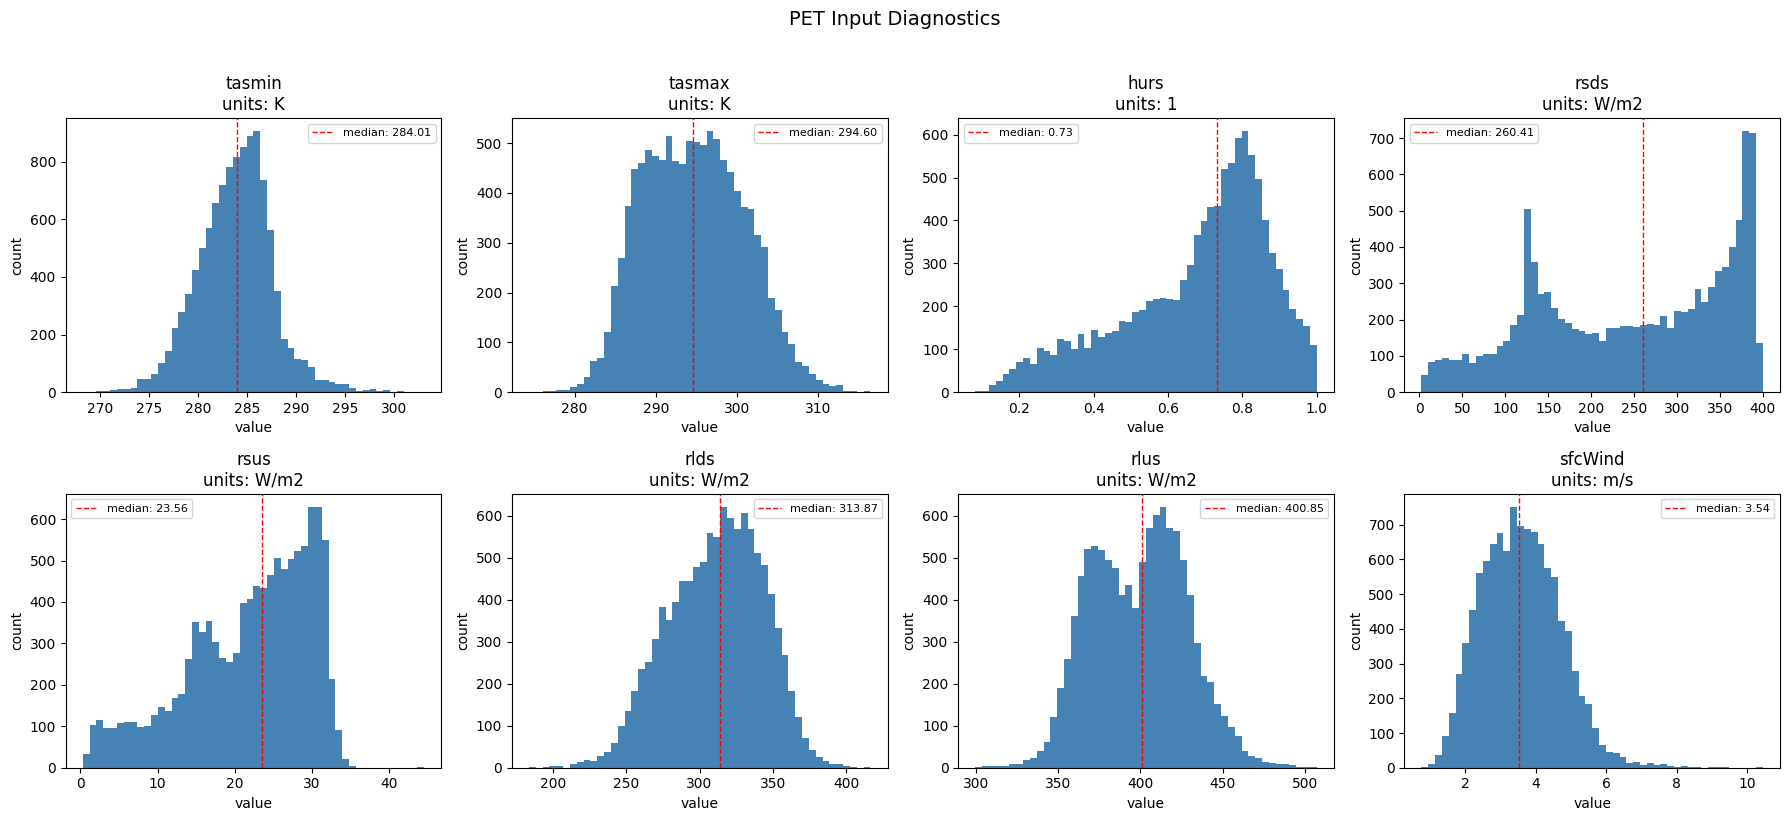

In [135]:
import matplotlib.pyplot as plt
import numpy as np

inputs = {
    'tasmin': tasmin.t2min,
    'tasmax': tasmax.t2max,
    'hurs': hurs_frac.rh,
    'rsds': sw_dwn.sw_dwn,
    'rsus': rsus_daily.swupb,
    'rlds': lw_dwn.lw_dwn,
    'rlus': rlus_daily.lwupb,
    'sfcWind': wspd10mean.wspd10mean,
}
inputs_sub = {name: da.isel(warming_level=1, sim=3) for name, da in inputs.items()}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, (name, da) in zip(axes, inputs_sub.items()):
    vals = da.values.flatten()
    vals = vals[~np.isnan(vals)]
    ax.hist(vals, bins=50, color='steelblue', edgecolor='none')
    ax.set_title(f"{name}\nunits: {da.attrs.get('units', 'NOT SET')}")
    ax.set_xlabel('value')
    ax.set_ylabel('count')
    ax.axvline(np.median(vals), color='red', linestyle='--', linewidth=1, label=f'median: {np.median(vals):.2f}')
    ax.legend(fontsize=8)

plt.suptitle('PET Input Diagnostics', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [166]:
# Grab rsus as an example to test out the distribution of values and ensure they look reasonable
rsus_testing = get_and_transform("swupb", table_id="1hr")


Fetching swupb...


/home/jovyan/src/climakitae/climakitae/util/utils.py:2020: UserWarning: 

Incomplete warming level for WRF.UCLA.EC-Earth3-Veg.ssp370.1hr.d03.r1i1p1f1 at 0.8C. 
Skipping this warming level.
  warnings.warn(


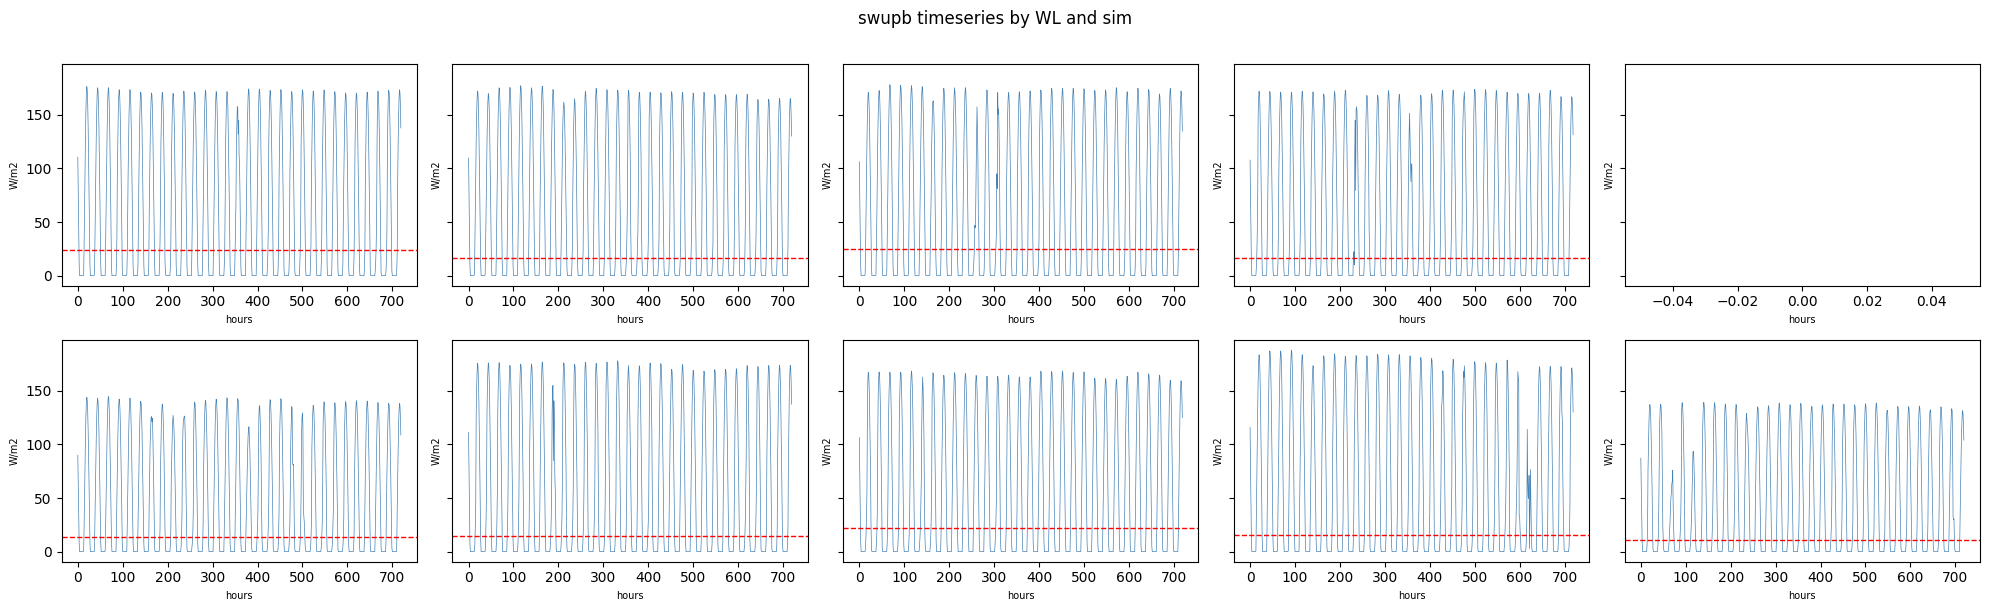

In [167]:
import matplotlib.pyplot as plt
import numpy as np

n_wl = rsus_testing.sizes['warming_level']
n_sim = rsus_testing.sizes['sim']

fig, axes = plt.subplots(n_wl, n_sim, figsize=(n_sim * 4, n_wl * 3), sharey=True)

for i, wl in enumerate(rsus_testing.warming_level.values):
    for j, sim in enumerate(rsus_testing.sim.values):
        ax = axes[i, j]
        vals = rsus_testing.sel(warming_level=wl, sim=sim).swupb.values[180*24: 210*24]  # first year hourly
        ax.plot(vals, linewidth=0.5, color='steelblue')
        ax.axhline(np.nanmedian(vals), color='red', linestyle='--', linewidth=1)
        # ax.set_title(f"WL={wl} | {sim}\nmedian={np.nanmedian(vals):.1f}", fontsize=8)
        ax.set_xlabel('hours', fontsize=7)
        ax.set_ylabel('W/m2', fontsize=7)

plt.suptitle('swupb timeseries by WL and sim', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

(array([4.6790e+03, 1.9767e+04, 1.7113e+04, 1.6921e+04, 2.5409e+04,
        1.0806e+04, 3.0500e+03, 6.7000e+02, 1.2000e+02, 1.5000e+01]),
 array([-0.00891502,  0.00670978,  0.02233457,  0.03795937,  0.05358417,
         0.06920896,  0.08483376,  0.10045855,  0.11608335,  0.13170815,
         0.14733294]),
 <BarContainer object of 10 artists>)

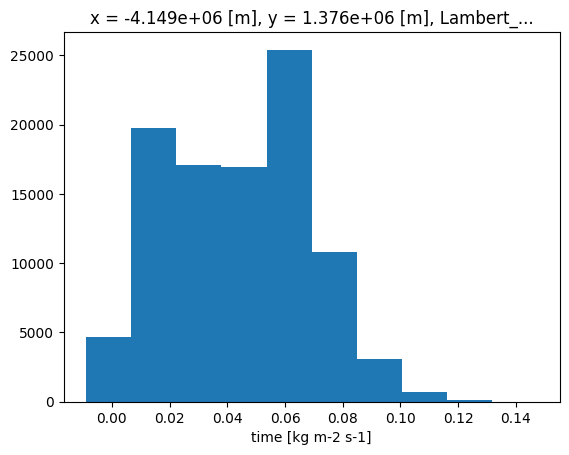

In [121]:
(loaded_pm).plot.hist()

## Step 2: Calculate PDSI

PDSI is registered as a derived variable using `register_user_function`. The underlying computation uses the `climate_indices` library's `palmer_pdsi` function — the same implementation referenced by drought.gov. The function is applied across all spatial and ensemble dimensions via `groupby().apply()`.

In [ ]:
# Resampling PET and precip to monthly since the function only takes monthly variables
one_prec = prec.sel(sim=prec.sim.str.contains(one_sim)).squeeze()
mon_pet    = (pet_calc * 86400 / 25.4).resample(time='1ME').sum()
mon_precip = (one_prec / 25.4).resample(time='1ME').sum()

In [ ]:
### Combining WL objects together, historical WL as 2000-2030, future WL as 2030-2060
def combine_wl_to_dummy_time(
    da: xr.DataArray,
    baseline_wl: float,
    future_wls: list[float],
    start_date: str = "2000-01-31",
) -> xr.DataArray:
    """
    Combine baseline warming level with multiple future warming levels into one
    DataArray along a new 'combined_wl' dimension.

    Parameters
    ----------
    da : xr.DataArray
        Original data with dims including 'warming_level' and 'time'.
    baseline_wl : float
        The warming level used for the first time segment.
    future_wls : list of float
        Warming levels to concatenate after baseline.
    start_date : str
        Start date for the combined time series (monthly freq).
    
    Returns
    -------
    xr.DataArray
        Combined DataArray with new dimension 'combined_wl' and coordinate labels like "0.8 to 1.5".
    """
    months_per_wl = da.sizes['time']
    total_months = 2 * months_per_wl
    new_time = pd.date_range(start_date, periods=total_months, freq='ME')

    combined_list = []
    combined_labels = []

    for fw in future_wls:
        da_base = da.sel(warming_level=baseline_wl)
        da_future = da.sel(warming_level=fw)

        combined = xr.concat([da_base, da_future], dim='time')
        combined = combined.assign_coords(time=new_time)

        wl_flag = np.array([baseline_wl] * months_per_wl + [fw] * months_per_wl)
        combined = combined.assign_coords(warming_level_flag=('time', wl_flag))

        combined_list.append(combined)
        combined_labels.append(f"{int(baseline_wl * 10):02d}_to_{int(fw * 10):02d}")

    combined_da = xr.concat(combined_list, dim='combined_wl')
    combined_da = combined_da.assign_coords(combined_wl=combined_labels)

    return combined_da

In [ ]:
# Creating one Dataset of PET and precip with WLs combined
mon_pet_transform = combine_wl_to_dummy_time(mon_pet, baseline_wl=WARMING_LEVELS[0], future_wls=WARMING_LEVELS[1:])
mon_precip_transform = combine_wl_to_dummy_time(mon_precip, baseline_wl=WARMING_LEVELS[0], future_wls=WARMING_LEVELS[1:])
mon_pet_transform = mon_pet_transform.assign_coords(mon_precip_transform.coords)
combined_ds = xr.Dataset({'precip': mon_precip_transform, 'pet': mon_pet_transform})

# Applying spatial mask
combined_ds = combined_ds.where(spatial_mask)

In [ ]:
def pdsi_func(ds: xr.Dataset) -> xr.Dataset:
    """Compute Palmer Drought Severity Index (PDSI) from a Dataset.

    Registered derived variable function: receives an xr.Dataset with 'precip' and
    'pet' variables (both monthly, in inches) and adds 'pdsi' to it.

    Parameters
    ----------
    ds : xr.Dataset
        Dataset with 'precip' and 'pet' variables along a 'time' dimension,
        plus 'combined_wl', 'sim', 'x', and 'y' dimensions.

    Returns
    -------
    xr.Dataset
        Input dataset with 'pdsi' variable added.
    """
    def _calc_pdsi_1d(timeseries: xr.Dataset) -> xr.DataArray:
        precip = timeseries['precip'].squeeze()
        pet    = timeseries['pet'].squeeze()
        result = palmer_pdsi(
            precips=precip.values,
            pet=pet.values,
            awc=5,
            data_start_year=2000,
            calibration_year_initial=2000,
            calibration_year_final=2030,
        )
        return xr.DataArray(
            result[0], coords={"time": precip.time.values}, dims=['time']
        ).clip(min=-10, max=10)

    pdsi_da = ds.groupby(['combined_wl', 'x', 'y']).apply(_calc_pdsi_1d)
    pdsi_da.attrs.update({
        "long_name": "Palmer Drought Severity Index",
        "units": "from -10 (dry) to +10 (wet)",
    })
    ds["pdsi"] = pdsi_da
    return ds

register_user_function(
    name="pdsi",
    depends_on=["precip", "pet"],
    func=pdsi_func,
    description="Palmer Drought Severity Index computed from monthly precipitation and PET.",
    units="unitless",
    drop_dependencies=False,
)

In [ ]:
# Apply PDSI derived variable to the combined dataset
pdsi_ds = list_derived_variables()["pdsi"].func(combined_ds)
pdsi_da = pdsi_ds["pdsi"]

# Writing crs and reprojecting PDSI to lat/lon
pdsi_da = pdsi_da.rio.write_crs(crs.to_wkt())
pdsi_da = pdsi_da.transpose('time', 'combined_wl', 'y', 'x')
# pdsi_latlon = reproject_data(pdsi_da, 'EPSG:4326')
# del pdsi_latlon.attrs["_FillValue"]

### Export PDSI

The combined time axis has 720 months total: months 0–359 are the baseline warming level (0.8°C, used for calibration), and months 360–719 are the future warming level period. The export below slices to `time=slice(360, 720)` to retain only the future period.

The exported file will have the following dimensions:
- `time`: 360 months (30-year future warming level period)
- `wl`: warming level pair (e.g., `"08_to_20"` = calibrated on 0.8°C, evaluated on 2.0°C)
- `lat`, `lon`: spatial coordinates (EPSG:4326)
- `sim`: ensemble member

In [ ]:
# Cleaning and labeling the data before exporting it in the next cell
final_pdsi = pdsi_da.isel(time=slice(360, 720))
final_pdsi = final_pdsi.rename({'combined_wl': 'wl'}).rename("pdsi")
final_pdsi = final_pdsi.assign_attrs({
    "long_name": "Palmer Drought Severity Index",
    "units": "from -10 (dry) to +10 (wet)",
})
pdsi_filename = f"pdsi_wl_lat{str(LAT).replace('.', '_')}_lon{str(LON).replace('.', '_')}.nc"

In [ ]:
export(final_pdsi, pdsi_filename, format="NetCDF", mode="local")

Exporting specified data to NetCDF...
Saving file locally as NetCDF4...


Exception: File pdsi_wl_lat37_787964_lon-122_065063.nc exists. Please either delete that file from the work space or specify a new file name here.

## Step 3: Calculate EDDI

Now, we will calculate EDDI using PET.

In [ ]:
def eddi_func(ds: xr.Dataset) -> xr.Dataset:
    """Compute Evaporative Demand Drought Index (EDDI) from a Dataset.

    Registered derived variable function: receives an xr.Dataset with a 'pet'
    variable (monthly) and adds 'eddi' to it.

    Parameters
    ----------
    ds : xr.Dataset
        Dataset with 'pet' variable along a 'time' dimension,
        plus 'combined_wl', 'sim', 'x', and 'y' dimensions.

    Returns
    -------
    xr.Dataset
        Input dataset with 'eddi' variable added.
    """
    def _calc_eddi_1d(timeseries: xr.DataArray) -> xr.DataArray:
        eddi = standardized_index(
            da=timeseries,
            freq='MS',
            window=1,
            dist="gamma",
            method="ML",
            zero_inflated=True,
            fitkwargs={},
            cal_start="2000-01-31",
            cal_end="2029-12-31",
        )
        return eddi.clip(min=-2.5, max=2.5)

    eddi_da = ds['pet'].groupby(['combined_wl', 'x', 'y']).apply(_calc_eddi_1d)
    eddi_da.attrs.update({
        "long_name": "Evaporative Demand Drought Index",
        "units": "from -2.5 (wet) to +2.5 (dry)",
    })
    ds["eddi"] = eddi_da
    return ds

register_user_function(
    name="eddi",
    depends_on=["pet"],
    func=eddi_func,
    description="Evaporative Demand Drought Index computed from monthly PET.",
    units="unitless",
    drop_dependencies=False,
)

In [ ]:
# Apply EDDI derived variable to the combined dataset
eddi_ds = list_derived_variables()["eddi"].func(combined_ds)
eddi_da = eddi_ds["eddi"]

# Writing crs and reprojecting EDDI to lat/lon
eddi_da = eddi_da.rio.write_crs(crs.to_wkt())
eddi_da = eddi_da.transpose('time', 'combined_wl', 'y', 'x')
# eddi_da_latlon = reproject_data(eddi_da, 'EPSG:4326')
# del eddi_da_latlon.attrs["_FillValue"]

KeyError: 'x'

### Export EDDI

The combined time axis has 720 months total: months 0–359 are the baseline warming level (0.8°C, used for calibration), and months 360–719 are the future warming level period. The export below slices to `time=slice(360, 720)` to retain only the future period.

The exported file will have the following dimensions:
- `time`: 360 months (30-year future warming level period)
- `wl`: warming level pair (e.g., `"08_to_20"` = calibrated on 0.8°C, evaluated on 2.0°C)
- `lat`, `lon`: spatial coordinates (EPSG:4326)
- `sim`: ensemble member

In [ ]:
# Saving these results and cleaning the data
final_eddi = eddi_da_latlon.isel(time=slice(360, 720))
final_eddi = final_eddi.rename({'combined_wl': 'wl'}).rename("eddi")
final_eddi = final_eddi.assign_attrs({
    "long_name": "Evaporative Demand Drought Index",
    "units": "from -2.5 (wet) to +2.5 (dry)",
})
eddi_filename = f"eddi_wl_lat{str(LAT).replace('.', '_')}_lon{str(LON).replace('.', '_')}.nc"

In [ ]:
export(final_eddi, eddi_filename, format="NetCDF", mode="local")